# 🧠 Introduction to CNNs for Image Classification

Until now, you've learned how to apply machine learning to structured datasets (like predicting prices or classifying data based on features). But how can we teach a machine to recognize images, like telling the difference between a **headlight**, a **bumper**, or a **wheel**?

That’s where **Convolutional Neural Networks (CNNs)** come in. CNNs are the **go-to architecture** in deep learning when it comes to visual understanding.

---

## 🧩 The Challenge with Image Data

Images are not like tabular data. A single color image of size 128×128 has **49,152 features** (128 × 128 × 3), which:
- Makes them **high-dimensional**
- Contains **spatial relationships** (e.g. a tire is round, and a headlight has glassy edges)
- Makes flattening them (as we did in ML) **lose important context**

Traditional ML methods treat all pixels independently. But CNNs understand **space** — they "look" at nearby pixels together, like how our eyes and brains work.

---

## 👁️ What is a CNN?

CNNs (Convolutional Neural Networks) are **neural networks designed specifically for images**. They learn patterns from raw pixel data through **filters** that scan the image.


![How a CNN Works](./images_gifs/cnnimage.png)


### Think of CNNs as layers of virtual eyes:
1. **Early layers** detect **edges**, **lines**, and **color patterns**
2. **Middle layers** detect **shapes**, **textures**, or **symmetry**
3. **Later layers** detect **parts**, **objects**, or **combinations**

All this happens without us manually designing the features. CNNs learn them during training.

---

![Digits](images_gifs/cnndigits.gif)

### 💡 How a CNN Works (Layer Ideas)

**Convolution Layer**
➤ Learns small visual patterns (like edges, curves, textures)
➤ Uses filters that slide over the image

**Activation (ReLU)**
➤ Keeps only useful signals (sets negatives to 0)
➤ Adds non-linearity so it can learn complex patterns

**Pooling Layer**
➤ Shrinks the feature maps (like zooming out)
➤ Keeps the strongest features (e.g., max pooling)

**More Conv + Pool Layers**
➤ Deeper layers learn higher-level parts (like car lights, tires)
➤ Each layer builds on the previous ones

**Flatten Layer**
➤ Turns 2D feature maps into a 1D vector
➤ Prepares data for the final decision

**Fully Connected (Dense) Layers**
➤ Combine all features to predict the class
➤ Similar to layers in traditional neural networks

**Softmax Output**
➤ Outputs class probabilities
➤ The highest value is the model’s prediction

![convs](images_gifs/convolutions.gif)

### Your Challenge:

In this notebook, we’ll train a CNN to recognize different **car parts** from images. These might include parts like:
- air compressor
- battery
- brake caliper
- coil spring
- oil pan and so on

**Total of 50 car parts**


You don’t need to **tell** the model what a headlight looks like — it will **learn** the patterns by itself from labeled training images.


By the end of this notebook, you'll be able to:

✅ Load and preprocess image data  
✅ Build your own CNN using TensorFlow/Keras  
✅ Train and evaluate the model  
✅ Visualize performance with graphs and confusion matrices  
✅ Experiment with changes and improve accuracy  


## 🖼️ Let's Look at Some Examples!

Before we start coding, here are some sample images from our dataset (randomly picked from different classes):

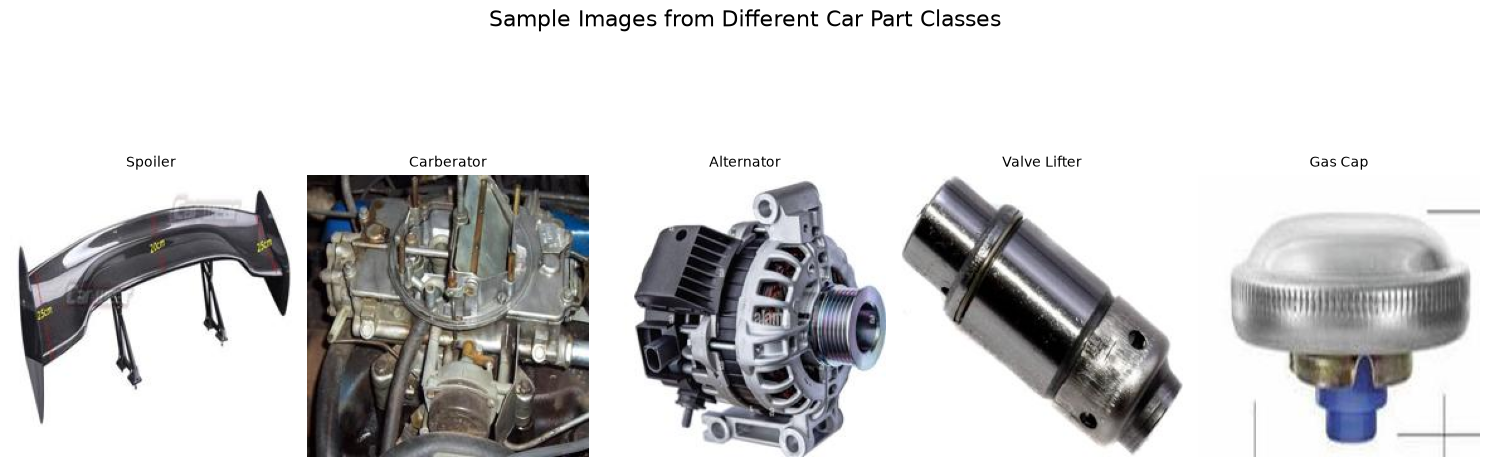

In [56]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from PIL import Image

dataset_path = './dataset/train'

class_dirs = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]

sampled_classes = random.sample(class_dirs, min(5, len(class_dirs)))

plt.figure(figsize=(15, 6))

for i, class_name in enumerate(sampled_classes):
    class_folder = os.path.join(dataset_path, class_name)
    
    valid_extensions = ['.jpg', '.jpeg', '.png']
    images_in_class = [f for f in os.listdir(class_folder)
                       if f.lower().endswith(tuple(valid_extensions)) and not f.startswith('.')]

    if not images_in_class:
        continue

    sample_image = random.choice(images_in_class)
    img_path = os.path.join(class_folder, sample_image)

    img = image.load_img(img_path, target_size=(224, 224))
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name.title(), fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Different Car Part Classes", fontsize=16)
plt.tight_layout()
plt.show()


In [57]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/car parts.csv')
df.head(20)

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train
5,0,train/AIR COMPRESSOR/006.jpg,AIR COMPRESSOR,train
6,0,train/AIR COMPRESSOR/007.jpg,AIR COMPRESSOR,train
7,0,train/AIR COMPRESSOR/008.jpg,AIR COMPRESSOR,train
8,0,train/AIR COMPRESSOR/009.jpg,AIR COMPRESSOR,train
9,0,train/AIR COMPRESSOR/010.jpg,AIR COMPRESSOR,train


In [58]:
label_counts = df['labels'].value_counts().sort_values(ascending=False)
label_counts

labels
IGNITION COIL           210
IDLER ARM               208
STARTER                 205
CARBERATOR              202
ALTERNATOR              200
OVERFLOW TANK           199
RADIO                   199
SHIFT KNOB              199
BRAKE PAD               198
ENGINE BLOCK            198
FUEL INJECTOR           198
OIL PAN                 197
OIL PRESSURE SENSOR     197
TORQUE CONVERTER        197
GAS CAP                 196
SIDE MIRROR             196
AIR COMPRESSOR          195
SPOILER                 195
CYLINDER HEAD           194
OXYGEN SENSOR           192
PRESSURE PLATE          192
THERMOSTAT              192
CLUTCH PLATE            191
CRANKSHAFT              190
INSTRUMENT CLUSTER      190
RIM                     189
WINDOW REGULATOR        189
VACUUM BRAKE BOOSTER    188
BATTERY                 187
BRAKE ROTOR             186
WATER PUMP              186
RADIATOR HOSE           185
VALVE LIFTER            185
BRAKE CALIPER           184
LOWER CONTROL ARM       179
OIL FILTER   

#### TODO: Research about data augmentation and what to do in case of an unbalanced dataset
##### At the end of the notebook, you can apply these techniques and train another CNN and compare results

### Your task: 

#### Quick CNN Workflow for Image Classification

1. **Load & preprocess data**  
   - Resize images and normalize pixel values (e.g., scale pixels to [0,1])  
   - Prepare labels for classification  

2. **Create training and validation data generators**  
   - Use `ImageDataGenerator` or custom loaders to batch and augment data  (If you want to, or skip this part for now)

3. **Build the CNN model**  
   - Stack convolutional layers (Conv2D + activation function) and pooling layers
   - Flatten and add dense layers for final classification  
   - Make sure to use the right activation function for the last Dense layer.

4. **Compile the model**  
   - Use suitable loss function nd an optimizer like Adam  

5. **Train the model**  
   - Fit the model on training data and validate on validation data over multiple epochs  
   - Find the right number of batches/epochs for your data

6. **Evaluate and visualize results**  
   - Plot Accuracy & Loss Curves for training/validation
   - Learn about overfitting/underfitting and how to prevent these situations 
   - Generate confusion matrix and classification report, based on metrics like accuracy

7. **Explore**
   - Use a pretrained available model
   - Change the architecture
   - Integrate the model into a small GUI and make it more interactive
   - Test with images from the internet, and see how well it performs


# Configurations

In [59]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

# reproducibility
SEED = 42
random.seed(SEED)
tf.random.set_seed(SEED)

# dataset paths
DATASET_DIR = Path("./dataset")
CSV_PATH = DATASET_DIR / "car parts.csv"

TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "valid"
TEST_DIR = DATASET_DIR / "test"

# image pipeline configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [60]:
split_directories = {
    "train": TRAIN_DIR,
    "valid": VALID_DIR,
    "test": TEST_DIR
}

for split_name, split_path in split_directories.items():
    if not split_path.exists():
        raise FileNotFoundError(
            f"The '{split_name}' directory was not found: {split_path}"
        )

    print(f"{split_name}: {split_path}")

train: dataset\train
valid: dataset\valid
test: dataset\test


In [61]:
print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (9239, 4)

Columns:
['class index', 'filepaths', 'labels', 'data set']


In [62]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
class index    0
filepaths      0
labels         0
data set       0
dtype: int64


In [63]:
number_of_classes = df["labels"].nunique()

print(f"Number of classes: {number_of_classes}")

Number of classes: 50


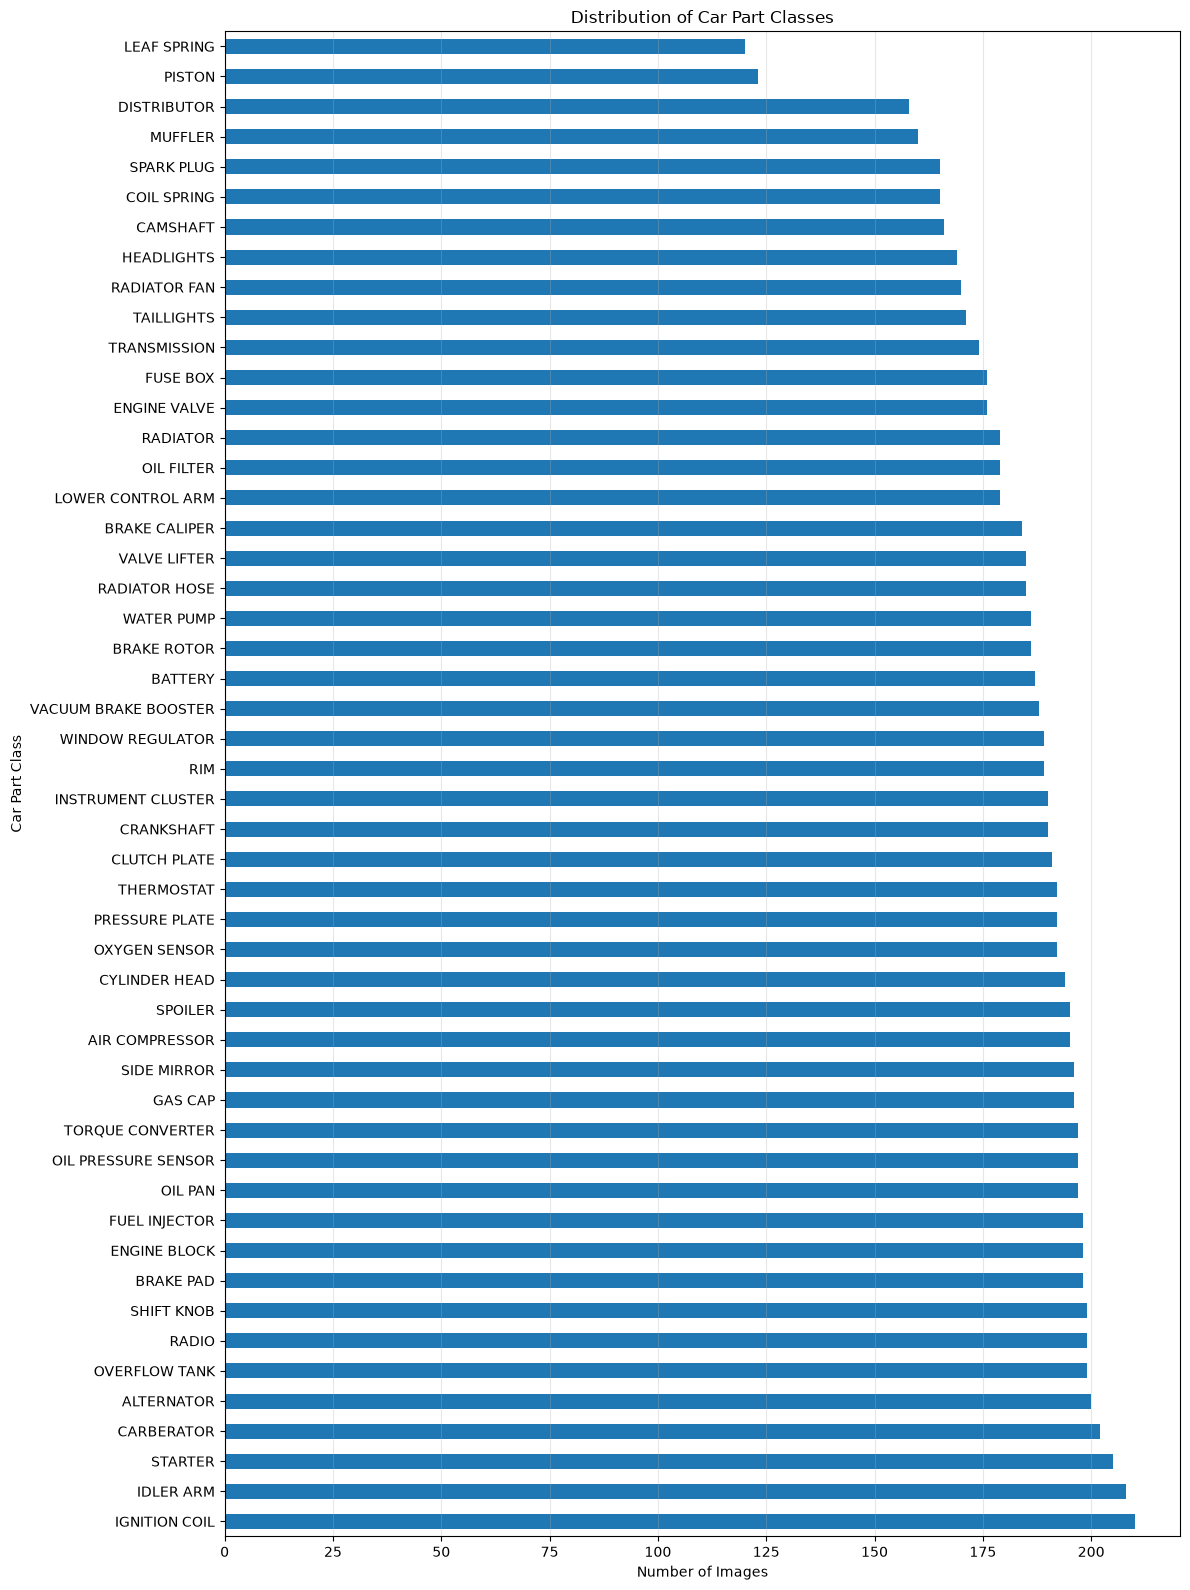

In [64]:
plt.figure(figsize=(12, 16))

label_counts.plot(kind="barh")

plt.title("Distribution of Car Part Classes")
plt.xlabel("Number of Images")
plt.ylabel("Car Part Class")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Class Distribution Observation

The dataset contains 50 car part classes. The number of images is not
identical for all classes, which indicates a degree of class imbalance.
However, the image loading pipeline will initially use all available
images without resampling.

# Pipeline for train, test, validation

In [65]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 8739 files belonging to 50 classes.


In [66]:
class_names = train_dataset.class_names

print(f"Number of classes: {len(class_names)}")
print("\nClass names:")
print(class_names)

assert len(class_names) == 50, (
    f"Expected 50 classes, but found {len(class_names)}."
)

Number of classes: 50

Class names:
['AIR COMPRESSOR', 'ALTERNATOR', 'BATTERY', 'BRAKE CALIPER', 'BRAKE PAD', 'BRAKE ROTOR', 'CAMSHAFT', 'CARBERATOR', 'CLUTCH PLATE', 'COIL SPRING', 'CRANKSHAFT', 'CYLINDER HEAD', 'DISTRIBUTOR', 'ENGINE BLOCK', 'ENGINE VALVE', 'FUEL INJECTOR', 'FUSE BOX', 'GAS CAP', 'HEADLIGHTS', 'IDLER ARM', 'IGNITION COIL', 'INSTRUMENT CLUSTER', 'LEAF SPRING', 'LOWER CONTROL ARM', 'MUFFLER', 'OIL FILTER', 'OIL PAN', 'OIL PRESSURE SENSOR', 'OVERFLOW TANK', 'OXYGEN SENSOR', 'PISTON', 'PRESSURE PLATE', 'RADIATOR', 'RADIATOR FAN', 'RADIATOR HOSE', 'RADIO', 'RIM', 'SHIFT KNOB', 'SIDE MIRROR', 'SPARK PLUG', 'SPOILER', 'STARTER', 'TAILLIGHTS', 'THERMOSTAT', 'TORQUE CONVERTER', 'TRANSMISSION', 'VACUUM BRAKE BOOSTER', 'VALVE LIFTER', 'WATER PUMP', 'WINDOW REGULATOR']


In [67]:
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 250 files belonging to 50 classes.


In [68]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 250 files belonging to 50 classes.


In [69]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .map(
        normalize_images,
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

valid_dataset = (
    valid_dataset
    .map(
        normalize_images,
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(
        normalize_images,
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

In [70]:
datasets = {
    "Train": train_dataset,
    "Validation": valid_dataset,
    "Test": test_dataset
}

for split_name, dataset in datasets.items():
    image_batch, label_batch = next(iter(dataset))

    minimum_pixel_value = tf.reduce_min(image_batch).numpy()
    maximum_pixel_value = tf.reduce_max(image_batch).numpy()

    print(f"\n{split_name} dataset")
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Label batch shape: {label_batch.shape}")
    print(f"Minimum pixel value: {minimum_pixel_value:.4f}")
    print(f"Maximum pixel value: {maximum_pixel_value:.4f}")

    assert minimum_pixel_value >= 0.0
    assert maximum_pixel_value <= 1.0


Train dataset
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0000
Maximum pixel value: 1.0000

Validation dataset
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0000
Maximum pixel value: 1.0000

Test dataset
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0000
Maximum pixel value: 1.0000


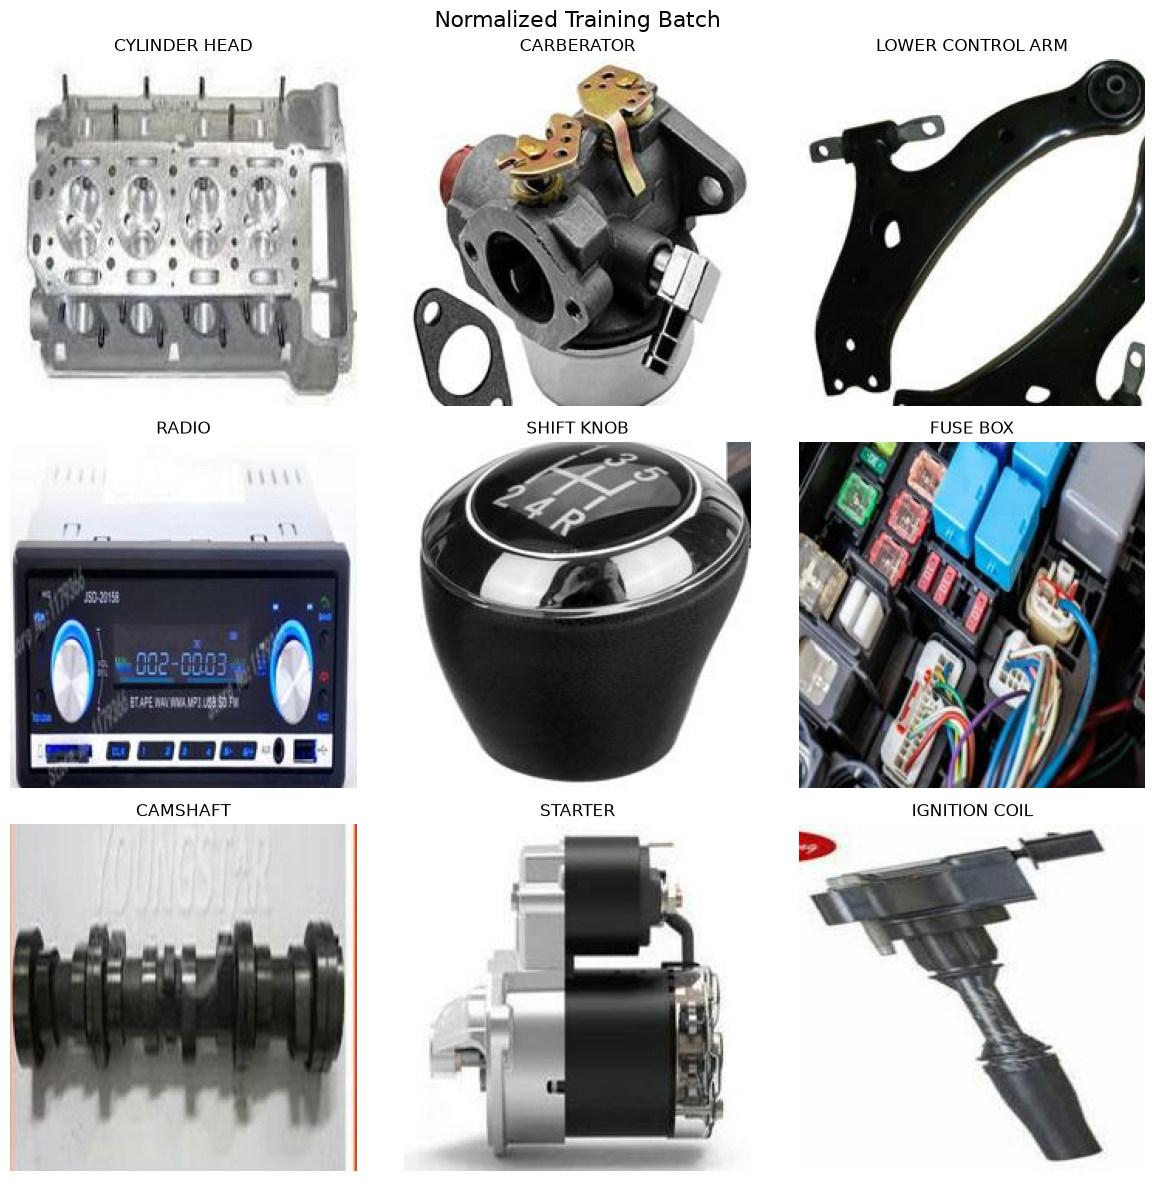

In [71]:
image_batch, label_batch = next(iter(train_dataset))

plt.figure(figsize=(12, 12))

for index in range(9):
    axis = plt.subplot(3, 3, index + 1)

    plt.imshow(image_batch[index].numpy())
    plt.title(
        class_names[int(label_batch[index].numpy())]
    )
    plt.axis("off")

plt.suptitle(
    "Normalized Training Batch",
    fontsize=16
)
plt.tight_layout()
plt.show()

## Conclusion

The image dataset was successfully explored and prepared for deep learning.
The metadata confirmed the presence of 50 car part classes, while the class
distribution plot and sample image grid provided an overview of the dataset
structure and image variety.

Separate data pipelines were created for the training, validation, and test
sets. The images were resized to 224x224 pixels, converted to RGB batches, and
normalized to the [0, 1] range. The batch inspection confirmed that the pipeline
returns images with the expected shape and one integer class label for each
image.

The dataset is now ready to be used for building and training a CNN
classification model.